In [176]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [177]:
# Analysing data

f = open("house_prices.csv", 'r')
X_list = []
for line in f:
    X_list.append(line.replace('\n', '').split(",")[2:])
print([[q, p] for q, p in zip(X_list[0], X_list[1])])
waterfront_variations = set()
condition_variations = set()
for i in range(1, len(X_list)):
    waterfront_variations.add(X_list[i][6]) # Defining all the possible variations of waterfront
    condition_variations.add(X_list[i][8]) # Defining all the possible variations of condition
print(f"waterfront_variations: {waterfront_variations}")
print(f"condition_variations: {condition_variations}")

f.close()

[['price', '221900.0'], ['bedrooms', '3'], ['bathrooms', '1.0'], ['sqft_living', '1180'], ['sqft_lot', '5650'], ['floors', '1.0'], ['waterfront', 'N'], ['view', '0'], ['condition', 'Average'], ['grade', '7'], ['sqft_above', '1180'], ['sqft_basement', '0'], ['yr_built', '1955'], ['yr_renovated', '0'], ['zipcode', '98178'], ['lat', '47.5112'], ['long', '-122.257'], ['sqft_living15', '1340'], ['sqft_lot15', '5650']]
waterfront_variations: {'N', 'Y'}
condition_variations: {'Good', 'Very Good', 'Average', 'Poor', 'Fair'}


In [178]:
# Make str features to type int

condition = {'Very Good': 5, 'Good': 4, 'Average': 3, 'Fair': 2, 'Poor': 1}
waterfront = {'N': 0, 'Y': 1}
for i in range(1, len(X_list)):
    X_list[i][8] = condition[X_list[i][8]]
    X_list[i][6] = waterfront[X_list[i][6]]
print(X_list[1])

['221900.0', '3', '1.0', '1180', '5650', '1.0', 0, '0', 3, '7', '1180', '0', '1955', '0', '98178', '47.5112', '-122.257', '1340', '5650']


In [179]:
# Create lists

features = X_list[0][1:]
Y_list = [float(x[0]) for x in X_list[1:]]
X_list = [[float(i) for i in x[1:]] for x in X_list[1:]]
print(f"features: {features}\nfull_list: {X_list[1]}\nlists: {Y_list[0]} {X_list[0]}")

features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
full_list: [3.0, 2.25, 2570.0, 7242.0, 2.0, 0.0, 0.0, 3.0, 7.0, 2170.0, 400.0, 1951.0, 1991.0, 98125.0, 47.721000000000004, -122.319, 1690.0, 7639.0]
lists: 221900.0 [3.0, 1.0, 1180.0, 5650.0, 1.0, 0.0, 0.0, 3.0, 7.0, 1180.0, 0.0, 1955.0, 0.0, 98178.0, 47.5112, -122.257, 1340.0, 5650.0]


<function matplotlib.pyplot.show(close=None, block=None)>

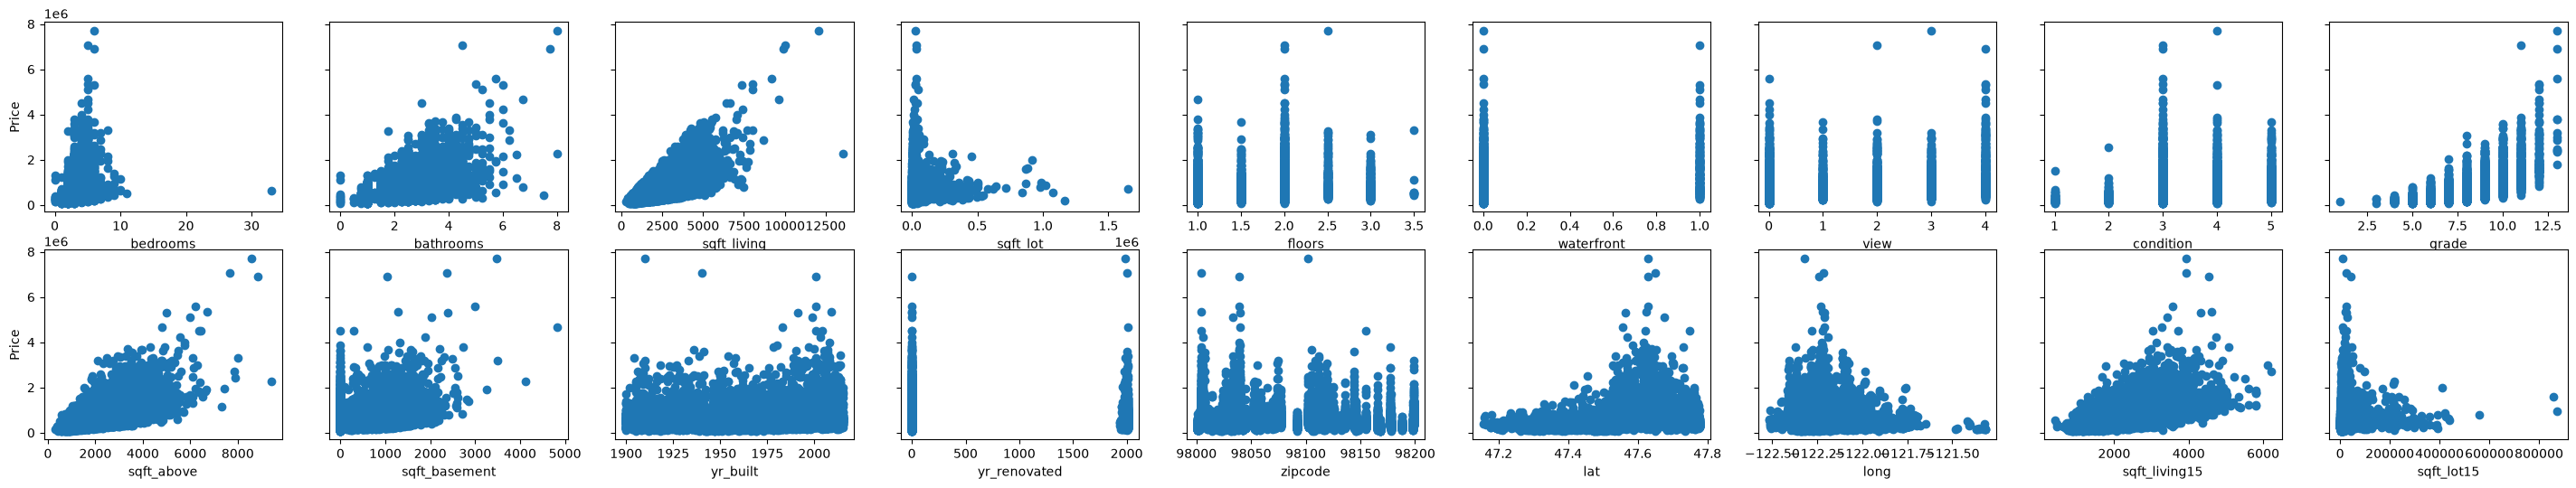

In [180]:
n = len(features)
cols = int(np.ceil(n / 2))

fig, ax = plt.subplots(2, cols, figsize=(4 * cols, 6), sharey=True)
ax = ax.flatten()

for i in range(n):
    ax[i].scatter([float(x[i]) for x in X_list], Y_list)
    ax[i].set_xlabel(features[i])

for a in ax[n:]:
    a.set_visible(False)

ax[0].set_ylabel('Price')
ax[cols].set_ylabel('Price')

plt.show

In [181]:
# Feature selection and creating numpy arrays

features_to_include = {0: 'bedrooms', 1: 'bathrooms', 2: 'sqft living', 8: 'grade', 9: 'sqft_above', 10: 'sqft_basement', 12: 'yr_renovated', 14: 'lat', 16: 'sqft_living15'}
final_features = [features_to_include[x] for x in range(len(features)) if x in features_to_include]
print(final_features)
X = np.array([[float(x[i]) for i in range(len(x)) if i in features_to_include] for x in X_list])
Y = np.array(Y_list)
print(f"x: {X[0]}, y: {Y[0]}")
        

['bedrooms', 'bathrooms', 'sqft living', 'grade', 'sqft_above', 'sqft_basement', 'yr_renovated', 'lat', 'sqft_living15']
x: [3.00000e+00 1.00000e+00 1.18000e+03 7.00000e+00 1.18000e+03 0.00000e+00
 0.00000e+00 4.75112e+01 1.34000e+03], y: 221900.0


In [182]:
# Normalize data with Z-score

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [189]:
# Creating class of my model

class MyModel:
    def __init__(self):
        self.b = 0
        self.w = np.zeros(len(final_features))
        self.loss_history = []

    def predict(self, X, normalisation=True):
        if normalisation:
            X = scaler.transform(X)
        return X @ self.w + self.b

    def fit(self, X, Y, lr=0.01, alpha=0.0001, epoches=1000):
        for epoch in range(1, epoches+1):
            pred = X @ self.w + self.b
            grad_w, grad_b = self.compute_grads(pred, alpha, Y, X)
            self.update_parameters(grad_w, grad_b, lr)

            loss = np.mean((pred - Y)**2)/2
            self.loss_history.append(loss)
            if epoch%10 == 0:
                print(f"Epoch: {epoch}. Loss: {loss}")

    def compute_grads(self, pred, alpha, Y, X):
        m = Y.shape[0]
        error = pred - Y

        grad_w = (X.T @ error) / m + (alpha / m) * self.w
        grad_b = np.mean(error)

        return grad_w, grad_b

    def update_parameters(self, grad_w, grad_b, lr):
        self.w-= lr*grad_w
        self.b-= lr*grad_b

Epoch: 10. Loss: 208017196093.71774
Epoch: 20. Loss: 202494719979.83023
Epoch: 30. Loss: 197242880766.02756
Epoch: 40. Loss: 192242872170.45914
Epoch: 50. Loss: 187477381071.51797
Epoch: 60. Loss: 182930464526.13422
Epoch: 70. Loss: 178587437009.5335
Epoch: 80. Loss: 174434767025.06168
Epoch: 90. Loss: 170459982303.63086
Epoch: 100. Loss: 166651582877.38416
Epoch: 110. Loss: 162998961371.79343
Epoch: 120. Loss: 159492329915.0564
Epoch: 130. Loss: 156122653113.75412
Epoch: 140. Loss: 152881586589.64856
Epoch: 150. Loss: 149761420614.5949
Epoch: 160. Loss: 146755028419.12494
Epoch: 170. Loss: 143855818785.6277
Epoch: 180. Loss: 141057692569.47394
Epoch: 190. Loss: 138355002821.14893
Epoch: 200. Loss: 135742518209.6996
Epoch: 210. Loss: 133215389472.77377
Epoch: 220. Loss: 130769118641.41794
Epoch: 230. Loss: 128399530808.78328
Epoch: 240. Loss: 126102748231.12178
Epoch: 250. Loss: 123875166567.08623
Epoch: 260. Loss: 121713433077.50677
Epoch: 270. Loss: 119614426622.63309
Epoch: 280. Los

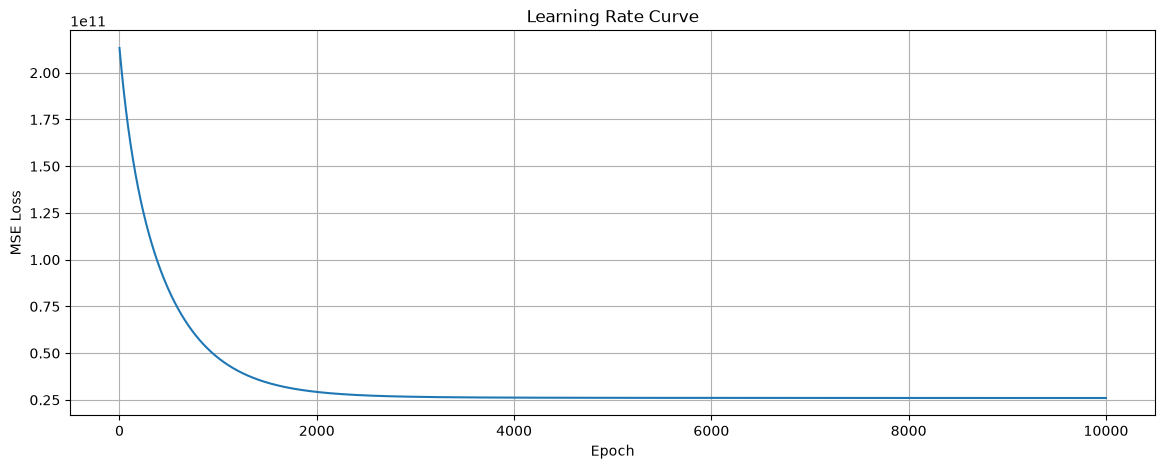

In [193]:
# Trying to get the best results

model = MyModel()
# model.fit(X, Y, epoches=100)
# model.fit(X, Y, epoches=100, lr=0.03)
model.fit(X, Y, epoches=10000, lr=0.001)

fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))

ax1.plot(model.loss_history)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Learning Rate Curve')
ax1.grid(True)